In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '4'

In [2]:
import os
import cv2
import glob
import math
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocessing
import tensorflow as tf
from pathlib import Path
import concurrent.futures
import keras.backend as K
from time import perf_counter
from functools import lru_cache
import matplotlib.pyplot as plt
from keras import layers, models
from keras.optimizers import Adam
from PIL import Image, ImageEnhance
from joblib import Parallel, delayed
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from keras.metrics import Precision, Recall, AUC
from keras.callbacks import LearningRateScheduler
from keras.utils import plot_model, to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Set global options for TensorFlow to optimize performance
try:
    tf.config.optimizer.set_jit(True)
    print("Just-In-Time (JIT) compilation has been enabled.")
except Exception as e:
    print("Could not enable Just-In-Time (JIT) compilation: ", e)

try:
    tf.config.threading.set_inter_op_parallelism_threads(4)
    print("Inter operation parallelism threads set to 4.")
except Exception as e:
    print("Could not set Inter operation parallelism threads: ", e)

try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    print("Intra operation parallelism threads set to 4.")
except Exception as e:
    print("Could not set Intra operation parallelism threads: ", e)

Just-In-Time (JIT) compilation has been enabled.
Inter operation parallelism threads set to 4.
Intra operation parallelism threads set to 4.


In [4]:
# Configure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
print(physical_devices)
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
#         tf.config.experimental.set_memory_growth(physical_devices[1], True)

        print("Memory growth has been enabled on the first GPU.")
    except:
        # Print error message if not able to configure the GPU
        print("Could not set memory growth.")
else:
    print("No GPU detected.")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth has been enabled on the first GPU.


In [5]:
# Enable mixed precision training
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision training has been enabled.")
except Exception as e:
    print("Could not enable mixed precision training: ", e)

Mixed precision training has been enabled.


In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print(dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [14]:
import os

def collect_data(dataset_root):
    """
    Collect image paths and labels from the Brain Tumor MRI Dataset.

    Args:
        dataset_root: Path containing Training/ and Testing/

    Returns:
        data, class_names
    """

    train_dir = os.path.join(dataset_root, "Training")
    test_dir  = os.path.join(dataset_root, "Testing")

    class_names = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])

    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

    data = []

    for split_dir in [train_dir, test_dir]:
        for class_name in class_names:
            class_dir = os.path.join(split_dir, class_name)

            if not os.path.isdir(class_dir):
                continue

            for img in os.listdir(class_dir):
                if img.lower().endswith((".jpg", ".jpeg", ".png")):
                    data.append({
                        "image_path": os.path.join(class_dir, img),
                        "label": class_to_idx[class_name]
                    })

    return data, class_names

In [15]:
import os

# Create data if it doesn't already exist
if "data" not in globals() or "class_names" not in globals():
    data, class_names = collect_data(dataset_path)

# Extract image paths and labels
image_paths = [item["image_path"] for item in data]
labels = [item["label"] for item in data]

# Format class names
formatted_class_names = [
    name.replace("_", " ").title()
    for name in class_names
]

print(f"Total images : {len(image_paths)}")
print(f"Classes      : {formatted_class_names}")

Total images : 7200
Classes      : ['Glioma', 'Meningioma', 'Notumor', 'Pituitary']


In [16]:
def is_black_and_white(image_path, label):
    """
    Process a single image and determine its color type.

    Parameters:
        image_path (str): File path of the image.
        label: Class label of the image.

    Returns:
        tuple: A tuple containing the label and color type ('Black & White' or 'Colored').
    """
    with Image.open(image_path) as image:
        color_type = 'Black & White' if image.mode == '1' else 'Colored'
    return label, color_type

In [ ]:
def count_images_per_class(image_paths, labels, class_names):
    """
    Count the number of black and white and colored images per class.

    Parameters:
        image_paths (list): List of file paths of the images.
        labels (list): List of corresponding class labels.
        class_names (dict): Dictionary mapping original class names to formatted class names.

    Returns:
        pandas.DataFrame: DataFrame containing the counts per class in tabular format.
    """
    data = defaultdict(lambda: {'Black & White': 0, 'Colored': 0})

    # Process images in parallel using ThreadPoolExecutor
    with ThreadPoolExecutor() as executor:
        processed_results = list(tqdm(executor.map(is_black_and_white, image_paths, labels), total=len(image_paths), desc="Processing images"))

    # Update counts based on processed results
    for label, color_type in processed_results:
        data[class_names[label]][color_type] += 1

    # Create DataFrame from the counts data
    df_data = {'Class': [], 'Black & White': [], 'Colored': []}
    for class_name, counts in data.items():
        df_data['Class'].append(class_name)
        df_data['Black & White'].append(counts['Black & White'])
        df_data['Colored'].append(counts['Colored'])

    df = pd.DataFrame(df_data)
    return df

# Count images per class and display the results
result_df = count_images_per_class(image_paths, labels, formatted_class_names)
print(result_df)

Processing images: 100%|██████████| 3264/3264 [00:00<00:00, 3942.15it/s]

              Class  Black & White  Colored
0      Glioma Tumor              0      926
1          No Tumor              0      500
2  Meningioma Tumor              0      937
3   Pituitary Tumor              0      901


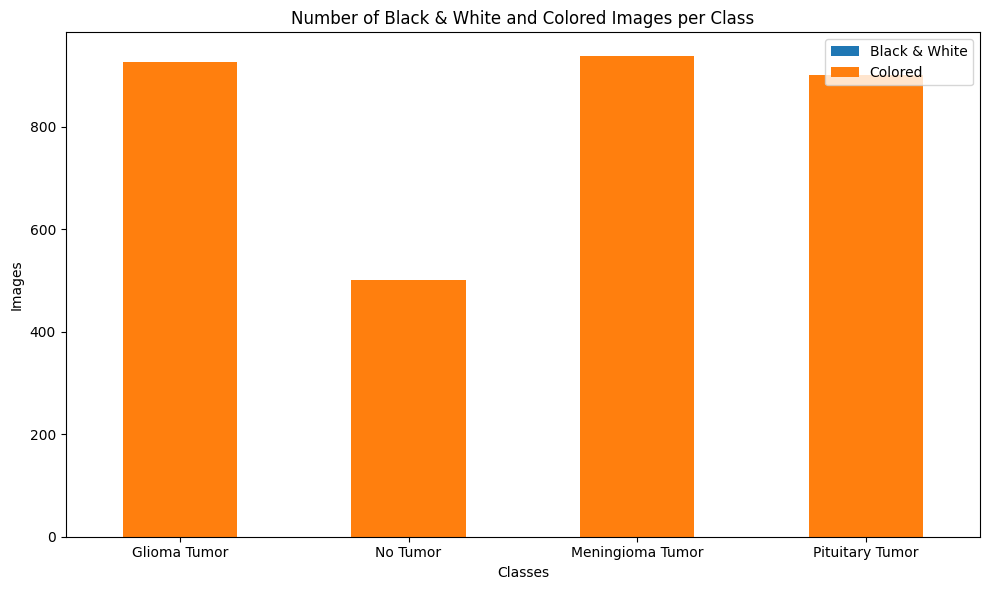

In [ ]:
def visualize_images_per_class(result_df, class_column='Class', bw_column='Black & White', colored_column='Colored'):
    """
    Visualize the number of black and white images and colored images per class.

    Parameters:
        result_df (pandas.DataFrame): DataFrame containing the counts per class.
        class_column (str): Name of the column containing the class labels.
        bw_column (str): Name of the column containing the count of black and white images.
        colored_column (str): Name of the column containing the count of colored images.

    Returns:
        None
    """
    # Set the 'Class' column as the DataFrame index for easy plotting
    result_df.set_index(class_column, inplace=True)

    # Plotting the data
    ax = result_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
    ax.set_xlabel('Classes')
    ax.set_ylabel('Images')
    ax.set_title('Number of Black & White and Colored Images per Class')
    ax.legend(["Black & White", "Colored"])

    plt.tight_layout()
    plt.show()

visualize_images_per_class(result_df)

In [18]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
classes = label_encoder.classes_
num_classes = len(classes)

In [19]:
train_paths, val_paths, train_labels, val_labels = train_test_split(image_paths,
                                                                      labels_encoded,
                                                                      test_size=0.2,
                                                                      random_state=42,
                                                                      stratify=labels_encoded)

train_paths, test_paths, train_labels, test_labels= train_test_split(train_paths,
                                                                    train_labels,
                                                                    test_size=0.2,
                                                                    random_state=42,
                                                                    stratify=train_labels)

In [ ]:
train_df = pd.DataFrame({'File Paths': train_paths, 'Labels': train_labels})
val_df = pd.DataFrame({'File Paths': val_paths, 'Labels': val_labels})
test_df = pd.DataFrame({'File Paths': test_paths, 'Labels': test_labels})

total_train_samples = len(train_df)
total_val_samples = len(val_df)
total_test_samples = len(test_df)

train_percentage = (total_train_samples / len(labels_encoded)) * 100
val_percentage = (total_val_samples / len(labels_encoded)) * 100
test_percentage = (total_test_samples / len(labels_encoded)) * 100

train_counts = train_df['Labels'].value_counts().sort_index()
val_counts = val_df['Labels'].value_counts().sort_index()
test_counts = test_df['Labels'].value_counts().sort_index()

train_df = pd.DataFrame({'Train Samples': train_counts})
val_df = pd.DataFrame({'Validation Samples': val_counts})
test_df = pd.DataFrame({'Test Samples': test_counts})

train_df.index = val_df.index = test_df.index = formatted_class_names

print("Total Train Samples:", total_train_samples)
print("Total Validation Samples:", total_val_samples)
print("Total Test Samples:", total_test_samples)
print("\nPercentage of Split:")
print("Train: {:.2f}%".format(train_percentage))
print("Validation: {:.2f}%".format(val_percentage))
print("Test: {:.2f}%".format(test_percentage))
print("\nClass Distribution:")
result_df = pd.concat([train_df, val_df, test_df], axis=1)
print(result_df)

Total Train Samples: 2088
Total Validation Samples: 653
Total Test Samples: 523

Percentage of Split:
Train: 63.97%
Validation: 20.01%
Test: 16.02%

Class Distribution:
                  Train Samples  Validation Samples  Test Samples
Glioma Tumor                592                 185           149
No Tumor                    320                 100            80
Meningioma Tumor            599                 188           150
Pituitary Tumor             577                 180           144


In [20]:
def image_generator(img_paths, img_labels, batch_size):
    """Generator function to load and preprocess images in batches.

    Args:
        img_paths (list): List of image file paths.
        img_labels (list): List of corresponding image labels.
        batch_size (int): Size of the batch.

    Yields:
        tuple: A tuple containing the batch of images and their corresponding labels.
    """
    num_samples = len(img_paths)

    while True:
        for offset in range(0, num_samples, batch_size):
            batch_paths = img_paths[offset:offset + batch_size]
            batch_labels = img_labels[offset:offset + batch_size]

            batch_images = []
            for img_path in batch_paths:
                image = cv2.imread(str(img_path))
                resized_image = cv2.resize(image, (224, 224))
                normalized_image = resized_image / 255.0
                batch_images.append(normalized_image)

            yield np.array(batch_images), to_categorical(batch_labels, num_classes)

In [21]:
BATCH_SIZE = 8

train_generator = image_generator(train_paths, train_labels, BATCH_SIZE)
train_steps = len(train_paths) // BATCH_SIZE

val_generator = image_generator(val_paths, val_labels, BATCH_SIZE)
val_steps = len(val_paths) // BATCH_SIZE

test_generator = image_generator(test_paths, test_labels, BATCH_SIZE)
test_steps = len(test_paths) // BATCH_SIZE

In [22]:
class AvgTwiceMaxPooling2D(layers.Layer):
    """
    Custom Keras layer that performs average - twice-maximum pooling on the input.

    Args:
        pool_size (int, optional): Pooling window size. Defaults to 2.
        strides (int, optional): Stride size for pooling. Defaults to 2.
        padding (str, optional): Padding mode ('same' or 'valid'). Defaults to 'same'.

    Returns:
        tf.Tensor: Output tensor after applying twice-maximum average pooling.
    """
    def __init__(self, pool_size=2, strides=2, padding='same', **kwargs):
        super(AvgTwiceMaxPooling2D, self).__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides
        self.padding = padding

    @tf.function
    def call(self, inputs, **kwargs):
        """
        Apply the average - twice-maximum pooling operation to the input tensor.

        Args:
            inputs (tf.Tensor): Input tensor.

        Returns:
            tf.Tensor: Output tensor after applying twice-maximum average pooling.
            :param **kwargs:
        """
        # Apply max pooling and average pooling
        max_pooled = layers.MaxPooling2D(pool_size=self.pool_size, strides=self.strides, padding=self.padding)(inputs)
        avg_pooled = layers.AveragePooling2D(pool_size=self.pool_size, strides=self.strides, padding=self.padding)(inputs)

        # Apply the average - twice-maximum pooling operation
        output = tf.subtract(avg_pooled, tf.add(max_pooled, max_pooled))
        return output

In [23]:
def process_image(image_path, p_s, s, p):
    """
    Process an image using layer.

    Args:
        image_path (str): The file path of the input image.
        p_s (tuple): The size of the pooling window (height, width).
        s (int): The stride of the pooling operation.
        p (str): The padding mode for pooling operation ('SAME' or 'VALID').

    Returns:
        tuple: A tuple containing the original image and the processed image after max pooling,
               negative transformation, and twice max-min pooling.
    """
    # Read the image from the file path
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0)

    # Create instances of custom layers
    avgtwicemaxpool_layer = AvgTwiceMaxPooling2D(pool_size=p_s, strides=s, padding=p)

    avgtwicemaxpool_image = avgtwicemaxpool_layer(image_tensor)

    # Squeeze the image tensors to remove the batch dimension
    avgtwicemaxpool_image = np.squeeze(avgtwicemaxpool_image.numpy(), axis=0)

    return image, avgtwicemaxpool_image

def visualize_results(cls_n, *img_t_ps):
    """
    Display images along with titles and corresponding class names in a matplotlib plot.

    Args:
        cls_n (str): Class name for the images.
        *img_t_ps: Variable number of image-title pairs as tuples.

    Raises:
        ValueError: If the number of image-title pairs is not 3.

    Returns:
        None
    """
    # Create a 1x3 subplot for displaying the images
    fig, axes = plt.subplots(1, 2)

    for i, (img_t, ax) in enumerate(zip(img_t_ps, axes)):
        img, title = img_t
        if not isinstance(img, np.ndarray):
            raise TypeError(f"Image {i+1} is not a valid numpy array.")
        if len(img.shape) != 3 or img.shape[2] != 3:
            raise ValueError(f"Image {i+1} is not a valid BGR image.")

        # Display the image and set the title
        ax.imshow(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [24]:
from tensorflow.keras.layers import LeakyReLU


In [25]:
import keras.backend as K

def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def channel_attention(input_feature, ratio=8):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = input_feature.shape[channel_axis]

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)
    avg_pool = shared_layer_one(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel//ratio)
    avg_pool = shared_layer_two(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1,1,channel))(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)
    max_pool = shared_layer_one(max_pool)
    assert max_pool.shape[1:] == (1,1,channel//ratio)
    max_pool = shared_layer_two(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

import tensorflow as tf

def spatial_attention(input_feature):
    kernel_size = 7

    if K.image_data_format() == "channels_first":
        channel = input_feature.shape[1]
        cbam_feature = Permute((2, 3, 1))(input_feature)
    else:
        channel = input_feature.shape[-1]
        cbam_feature = input_feature

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True), output_shape=lambda s: (s[0], s[1], s[2], 1))(cbam_feature)
    assert avg_pool.shape[-1] == 1
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True), output_shape=lambda s: (s[0], s[1], s[2], 1))(cbam_feature)
    assert max_pool.shape[-1] == 1
    concat = Concatenate(axis=3)([avg_pool, max_pool])
    assert concat.shape[-1] == 2
    cbam_feature = Conv2D(filters=1,
                          kernel_size=kernel_size,
                          strides=1,
                          padding='same',
                          activation='sigmoid',
                          kernel_initializer='he_normal',
                          use_bias=False)(concat)
    assert cbam_feature.shape[-1] == 1

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])



In [26]:
def residual_block(y, nb_channels, _strides=(1, 1), _project_shortcut=False):
    shortcut = y

    # down-sampling is performed with a stride of 2
    y = Conv2D(nb_channels, kernel_size=(3, 3), strides=_strides, padding='same')(y)
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)

    y = Conv2D(nb_channels, kernel_size=(3, 3), strides=(1, 1), padding='same')(y)
    y = BatchNormalization()(y)

    # identity shortcuts used directly when the input and output are of the same dimensions
    if _project_shortcut or _strides != (1, 1):
        # when the dimensions increase projection shortcut is used to match dimensions (done by 1×1 convolutions)
        # when the shortcuts go across feature maps of two sizes, they are performed with a stride of 2
        shortcut = Conv2D(nb_channels, kernel_size=(1, 1), strides=_strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    y = add([shortcut, y])
    y = LeakyReLU()(y)

    return y

In [27]:
from albumentations import *
from skimage.transform import resize


from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

from keras.layers import *
from keras.callbacks import *
from keras.optimizers import *
from keras.models import load_model, Model

def create_model():
    input_shape = (224, 224, 3)  # Example shape, adjust according to your input size

    # Ensure consistent data type
    dtype = 'float32'

    drop_rate = 0.3

    init = Input(shape=input_shape, dtype=dtype)
    x = Conv2D(32, (3, 3), activation=None, padding='same', dtype=dtype)(init)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, (3, 3), activation=None, padding='same', dtype=dtype)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x1 = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3, 3), activation=None, padding='same', dtype=dtype)(x1)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x)  # Assuming cbam_block is defined
    x = residual_block(x, 64)  # Assuming residual_block is defined
    x2 = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3, 3), activation=None, padding='same', dtype=dtype)(x2)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x)  # Assuming cbam_block is defined
    x = residual_block(x, 128)  # Assuming residual_block is defined
    x3 = MaxPooling2D((2,2))(x)

    ginp1 = UpSampling2D(size=(2, 2), interpolation='bilinear')(x1)
    ginp2 = UpSampling2D(size=(4, 4), interpolation='bilinear')(x2)
    ginp3 = UpSampling2D(size=(8, 8), interpolation='bilinear')(x3)

    hypercolumn = Concatenate()([ginp1, ginp2, ginp3])
    gap = GlobalAveragePooling2D()(hypercolumn)

    x = Dense(256, activation=None, dtype=dtype)(gap)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(drop_rate)(x)

    x = Dense(256, activation=None, dtype=dtype)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    output = Dense(4, activation='softmax')(x)

    model = Model(init, output)
    return model



In [28]:
model = create_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 8)   │        520 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        576 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 606,080 (2.31 MB)

 Trainable params: 603,776 (2.30 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [29]:
plot_model(model, show_shapes=True)

In [30]:
import tensorflow as tf
import tensorflow.keras.backend as K

def create_metrics():
    """
    Creates instances of various metrics for evaluating model performance.

    Returns:
        tuple: A tuple of the metrics: (recall, precision, f1_score, auc, sensitivity, specificity, mcc).
    """
    @tf.function
    def f1_score(y_true, y_pred):
        """
        Calculates the F1 score.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: F1 score.
        """
        tp = true_positive(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        precision = tp / (tp + fp + K.epsilon())
        recall = tp / (tp + fn + K.epsilon())

        return 2 * (precision * recall) / (precision + recall + K.epsilon())

    @tf.function
    def specificity(y_true, y_pred):
        """
        Calculates the specificity.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Specificity.
        """
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)

        return tn / (tn + fp + K.epsilon())

    @tf.function
    def sensitivity(y_true, y_pred):
        """
        Calculates the sensitivity.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Sensitivity.
        """
        tp = true_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        return tp / (tp + fn + K.epsilon())

    @tf.function
    def mcc(y_true, y_pred):
        """
        Calculates the Matthews correlation coefficient (MCC).

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Matthews correlation coefficient.
        """
        tp = true_positive(y_true, y_pred)
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        numerator = (tp * tn - fp * fn)
        denominator = K.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

        return numerator / (denominator + K.epsilon())

    @tf.function
    def true_positive(y_true, y_pred):
        """
        Calculates the number of true positives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of true positives.
        """
        y_pred_pos, _, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return K.sum(y_pos * y_pred_pos)

    @tf.function
    def false_positive(y_true, y_pred):
        """
        Calculates the number of false positives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of false positives.
        """
        y_pred_pos, _, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return K.sum(y_neg * y_pred_pos)

    @tf.function
    def false_negative(y_true, y_pred):
        """
        Calculates the number of false negatives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of false negatives.
        """
        _, y_pred_neg, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return K.sum(y_pos * y_pred_neg)

    @tf.function
    def true_negative(y_true, y_pred):
        """
        Calculates the number of true negatives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of true negatives.
        """
        _, y_pred_neg, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return K.sum(y_neg * y_pred_neg)

    @tf.function
    def calculate_confusion_matrix(y_true, y_pred):
        """
        Calculates the components of the confusion matrix.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            tuple: A tuple containing the components of the confusion matrix: (y_pred_pos, y_pred_neg, y_pos, y_neg).
        """
        y_true = K.cast(y_true, 'float32')  # Casting y_true to float32
        y_pred = K.cast(y_pred, 'float32')  # Casting y_pred to float32

        y_pred_pos = K.round(K.clip(y_pred, 0, 1))
        y_pred_neg = 1 - y_pred_pos
        y_pos = K.round(K.clip(y_true, 0, 1))
        y_neg = 1 - y_pos
        return y_pred_pos, y_pred_neg, y_pos, y_neg

    precision_metric = Precision()
    recall_metric = Recall()
    f1_score_metric = f1_score
    specificity_metric = specificity
    sensitivity_metric = sensitivity
    mcc_metric = mcc
    auc_metric = AUC()

    return (
        precision_metric,
        recall_metric,
        f1_score_metric,
        specificity_metric,
        sensitivity_metric,
        mcc_metric,
        auc_metric,
    )


In [31]:
metrics = ["accuracy"]
metrics.extend(list(create_metrics()))

model.compile(
    optimizer = Adam(learning_rate = 5e-4),
    loss = 'categorical_crossentropy',
    metrics = metrics
)

In [32]:
class TimeCallback(tf.keras.callbacks.Callback):
    """Custom callback to record epoch times and total training time."""

    def on_train_begin(self, logs=None):
        """Initialize training start time and epoch times."""
        self.train_start_time = time.perf_counter()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        """Record start time of each epoch."""
        self.epoch_start_time = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        """Calculate and store epoch time."""
        epoch_time = time.perf_counter() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

    def on_train_end(self, logs=None):
        """Calculate total training time."""
        self.total_train_time = time.perf_counter() - self.train_start_time

# Create an instance of the TimeCallback
time_callback = TimeCallback()

In [34]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Automatically get the correct input size
_, H, W, C = model.input_shape

@tf.function
def model_fn(x):
    return model(x)

concrete_func = model_fn.get_concrete_function(
    tf.TensorSpec([1, H, W, C], tf.float32)
)

frozen_func = convert_variables_to_constants_v2(concrete_func)
graph = frozen_func.graph

with graph.as_default():
    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        options=tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    )

print("="*60)
print(f"Input Shape : {model.input_shape}")
print(f"Parameters  : {model.count_params():,}")
print(f"Params (M)  : {model.count_params()/1e6:.3f}")
print(f"FLOPs       : {flops.total_float_ops:,}")
print(f"GFLOPs      : {flops.total_float_ops/1e9:.3f}")
print("="*60)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Input Shape : (None, 224, 224, 3)
Parameters  : 606,080
Params (M)  : 0.606
FLOPs       : 5,702,140,040
GFLOPs      : 5.702


In [ ]:
TOTAL_EPOCHS = 25

start_time = perf_counter()
history = model.fit(
    train_generator,
    epochs=TOTAL_EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=[time_callback]
)
end_time = perf_counter()

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 71s 106ms/step - accuracy: 0.4766 - auc: 0.7202 - f1_score: 0.3880 - loss: 1.2719 - mcc: 0.2638 - precision: 0.5233 - recall: 0.3268 - sensitivity: 0.3268 - specificity: 0.9043 - val_accuracy: 0.1543 - val_auc: 0.4103 - val_f1_score: 0.1529 - val_loss: 3.8926 - val_mcc: -0.1282 - val_precision: 0.1537 - val_recall: 0.1528 - val_sensitivity: 0.1528 - val_specificity: 0.7197
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - accuracy: 0.5860 - auc: 0.8229 - f1_score: 0.5635 - loss: 1.0214 - mcc: 0.4580 - precision: 0.6637 - recall: 0.4970 - sensitivity: 0.4970 - specificity: 0.9160 - val_accuracy: 0.4775 - val_auc: 0.6903 - val_f1_score: 0.4711 - val_loss: 1.7986 - val_mcc: 0.3042 - val_precision: 0.4901 - val_recall: 0.4589 - val_sensitivity: 0.4577 - val_specificity: 0.8403
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.6269 - auc: 0.8535 - f1_score: 0.5904 - loss: 0.9213 - mcc: 0.4879 - precision: 0.6792 - recall: 0.53

In [ ]:
execution_time_parts = []
avg_time_parts = []

for unit in [(3600, 'hours'), (60, 'minutes'), (1, 'seconds'), (0.001, 'milliseconds')]:
    total_value = int(time_callback.total_train_time // unit[0])
    avg_value = int(np.mean(time_callback.epoch_times) // unit[0])

    if total_value > 0 or unit[0] == 0.001:
        execution_time_parts.append((total_value, unit[1]))
    if avg_value > 0 or unit[0] == 0.001:
        avg_time_parts.append((avg_value, unit[1]))

    time_callback.total_train_time -= total_value * unit[0]
    time_callback.epoch_times = [time - avg_value * unit[0] for time in time_callback.epoch_times]

execution_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in execution_time_parts if value > 0
])

avg_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in avg_time_parts if value > 0
])

print(f"Model training took {execution_time_string}")
print(f"Average time per epoch: {avg_time_string}")

Model training took 10 minutes, 42 seconds, 728 milliseconds
Average time per epoch: 25 seconds, 686 milliseconds


In [ ]:
_ = model.evaluate(test_generator, steps=test_steps)

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5923 - auc: 0.8135 - f1_score: 0.5946 - loss: 1.9289 - mcc: 0.4609 - precision: 0.5986 - recall: 0.5914 - sensitivity: 0.5914 - specificity: 0.8677


In [ ]:
def plot_metrics(hist, metric_name_list):
    """
    Plots the given metrics for the training and validation sets.

    Args:
        hist: a Keras History object containing the training history
        metric_name_list: a list of strings representing the names of the metrics to plot

    Returns:
        None
    """
    num_metrics = len(metric_name_list)

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    rng = range(1, len(hist.history[metric_name_list[0]]) + 1)

    for ax, metric_n in zip(axes, metric_name_list):
        metric = hist.history[metric_n]
        v_metric = hist.history[f"val_{metric_n}"]

        ax.plot(rng, metric, label=metric_n)
        ax.plot(rng, v_metric, label=f"val_{metric_n}")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_n in ("auc", "mcc"):
            ax.set_ylabel(metric_n.upper())
            ax.set_title(metric_n.upper() + " vs Epochs")
        else:
            ax.set_ylabel(metric_n.capitalize())
            ax.set_title(metric_n.capitalize() + " vs Epochs")

        max_loss = max(max(metric), max(v_metric))
        min_loss = min(min(metric), min(v_metric))
        y_max = math.ceil(max_loss)

        if min_loss > 0 or max_loss > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_loss, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(1, len(metric))

    plt.tight_layout()

    plt.show()

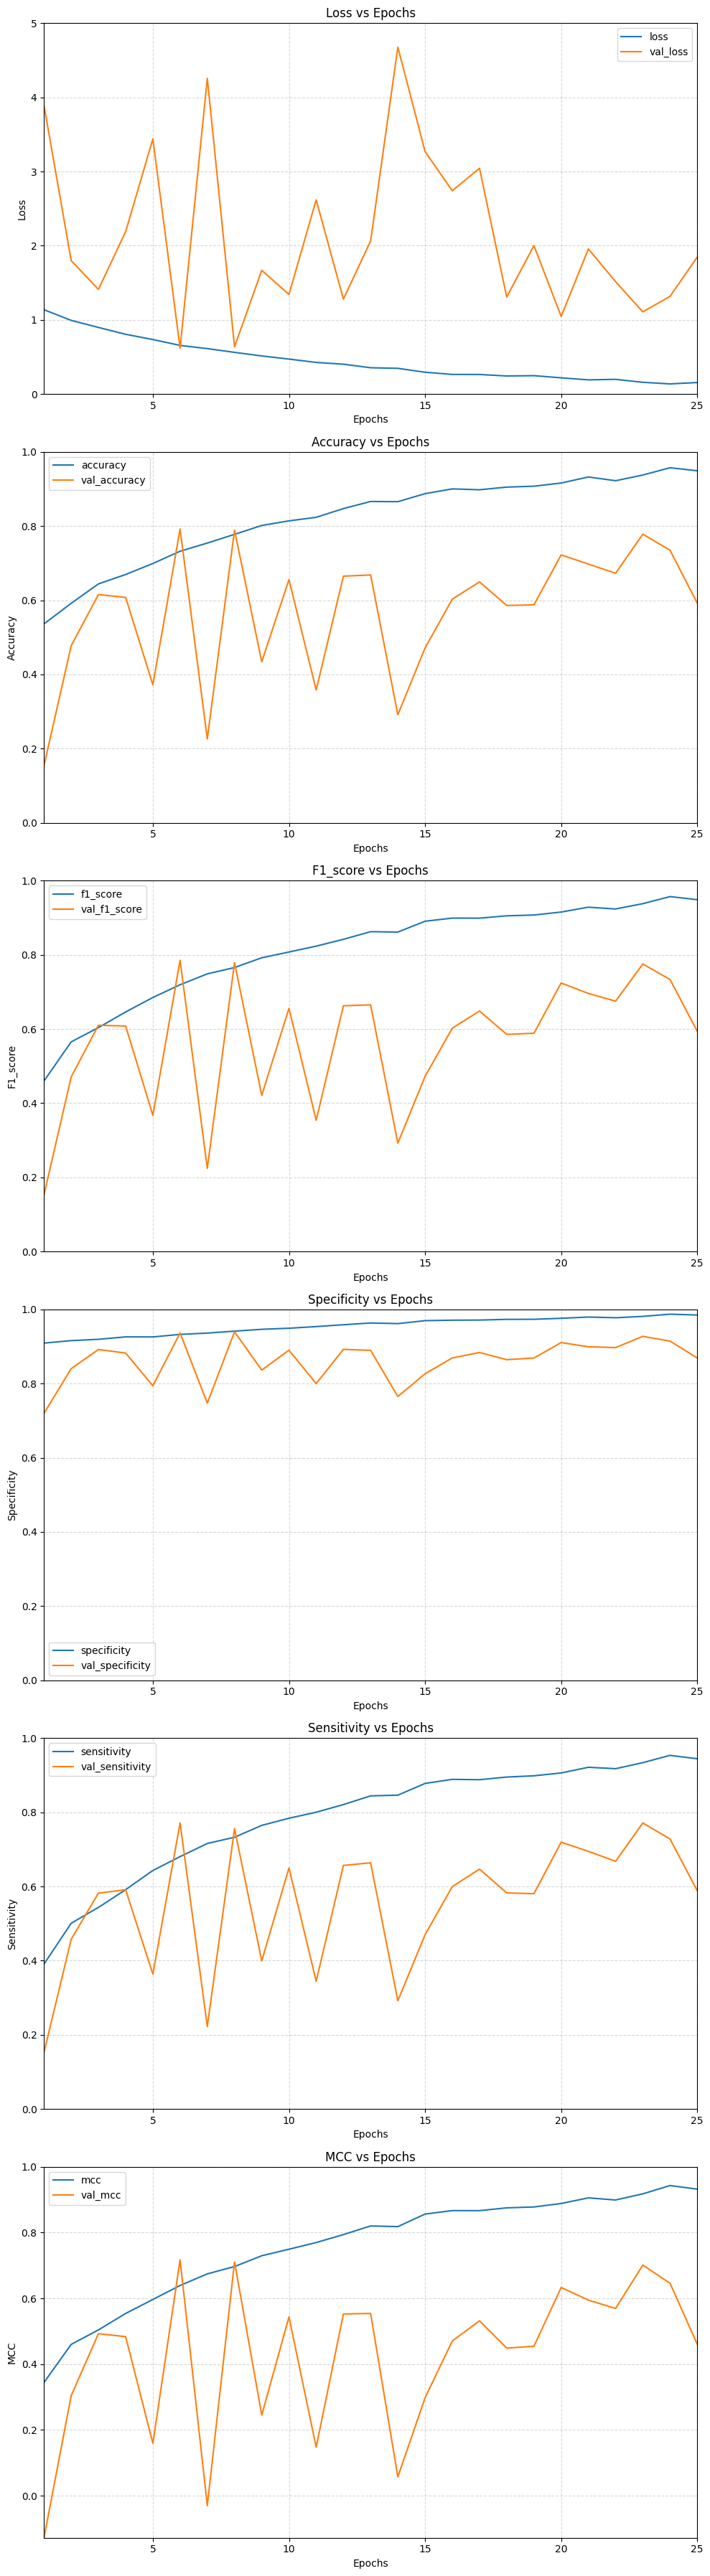

In [ ]:
metric_names = ["loss", "accuracy","f1_score",
                "specificity", "sensitivity", "mcc"]
plot_metrics(history, metric_names)

In [ ]:
def generate_classification_report(model, test_generator, test_steps, batch_size, target_names):
    """
    Generate a classification report, accuracy, and number of errors for a given model and test generator.

    Args:
        model (object): The trained model.
        test_generator (object): The test data generator.
        test_steps (int): The number of steps to iterate over the test generator.
        batch_size (int): The batch size for generating predictions.
        target_names (list): List of target class names for the classification report.

    Returns:
        tuple: A tuple containing true labels, predicted labels, and the classification report.
    """
    predicted_labels = []
    true_labels = []

    for i in range(test_steps):
        batch_data, batch_true_labels = next(test_generator)

        batch_predicted_labels = model.predict_on_batch(batch_data)
        batch_predicted_labels = np.argmax(batch_predicted_labels, axis=1)

        predicted_labels.extend(batch_predicted_labels)
        true_labels.extend(batch_true_labels)

    true_labels = np.array(true_labels)

    if len(true_labels[0]) > 1:
        true_labels = np.argmax(true_labels, axis=1)

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=target_names,
        digits=4,
        zero_division=1
    )

    accuracy = accuracy_score(true_labels, predicted_labels)
    num_errors = np.sum(true_labels != predicted_labels)

    print(report)
    print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy*100:6.2f}')

    return true_labels, predicted_labels

In [ ]:
true_labels, predicted_labels = generate_classification_report(
    model, test_generator, test_steps, BATCH_SIZE, formatted_class_names
)

                  precision    recall  f1-score   support

    Glioma Tumor     0.6135    0.6757    0.6431       148
        No Tumor     0.3883    1.0000    0.5594        80
Meningioma Tumor     1.0000    0.2000    0.3333       150
 Pituitary Tumor     0.9091    0.7746    0.8365       142

        accuracy                         0.6154       520
       macro avg     0.7277    0.6626    0.5931       520
    weighted avg     0.7711    0.6154    0.5937       520

There were 200 errors in 520 tests for an accuracy of  61.54


In [ ]:
def confusion_matrix(true_labels, predicted_labels, num_classes):
    """
    Compute the confusion matrix.

    Args:
        true_labels (list or numpy.ndarray): Array-like object of true labels.
        predicted_labels (list or numpy.ndarray): Array-like object of predicted labels.
        num_classes (int): Number of classes.

    Returns:
        numpy.ndarray: Confusion matrix.
    """
    cm = np.zeros((num_classes, num_classes), dtype=int)
    np.add.at(cm, (true_labels, predicted_labels), 1)
    return cm

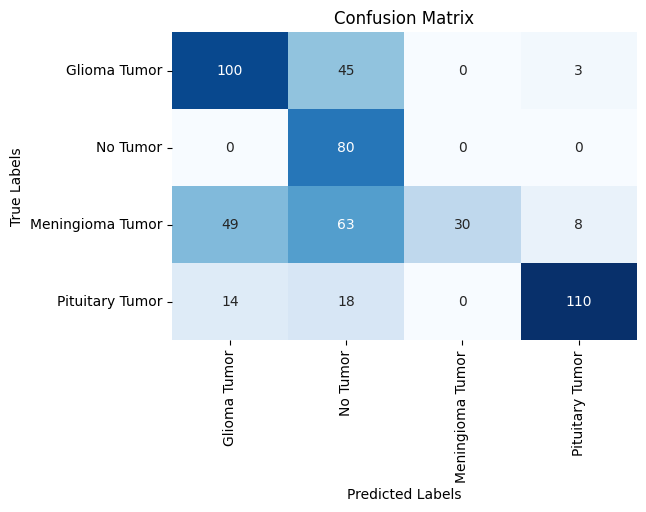

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels, num_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=formatted_class_names, yticklabels=formatted_class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()